# Dissect short ncRNA alignment (single job)

This notebook mirrors the short ncRNA scoring logic, but runs locally without the GPU executor service. It loads RNA-FM directly, applies the same PCA projection, and reproduces window scanning + perturbation.


In [ ]:
from pathlib import Path
# --- Paste a job line from short_ncRNA_joblist.txt ---
# Format: transcript_id, chain_id, biotype, transcript_region, transcript_strand, query_region, query_strand
job_string = "U_ENSG00000278278.1	186	miRNA	chr22:20114685-20114751	-1	chr16:18069188-18069491	1"

# --- Required paths (edit) ---
repo_root = Path("/Users/Bogdan.Kirilenko/Developer/CURIA_pipeline")
union_bed_path = repo_root / "sample_output" / "union_transcripts.bed"   # adjust
ref_2bit_path = repo_root / "input_data" / "2bit" / "hg38.2bit"          # adjust
query_2bit_path = repo_root / "input_data" / "2bit" / "mm39.2bit"            # adjust

# --- Scoring parameters (match pipeline defaults unless changed) ---
flank_ratio = 0.1
min_length_ratio = 0.8
max_length_ratio = 1.2
window_step = 1
perturbation_range = 5
max_batch = 128  # match --gpu-max-batch if you changed it

In [2]:
import sys
from pathlib import Path
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Make project modules importable
sys.path.insert(0, str(repo_root / "modules" / "utils"))
sys.path.insert(0, str(repo_root / "modules" / "RNA-FM"))

import short_ncrna as sn
import fm
from pyrion import TwoBitAccessor


In [3]:
# Parse job string
parts = job_string.strip().split("	")
if len(parts) != 7:
    raise ValueError("job_string must have 7 tab-separated fields")

job = sn.ShortRNAJob(
    transcript_id=parts[0],
    chain_id=parts[1],
    biotype=parts[2],
    transcript_region=parts[3],
    transcript_strand=int(parts[4]),
    query_region=parts[5],
    query_strand=int(parts[6]),
)
job


ShortRNAJob(transcript_id='U_ENSG00000278278.1', chain_id='186', biotype='miRNA', transcript_region='chr22:20114685-20114751', transcript_strand=-1, query_region='chr16:18069188-18069491', query_strand=1)

In [ ]:
# Load transcripts and extract reference sequence
transcripts = sn.pyrion.io.read_bed12_file(str(union_bed_path))
transcripts_by_id = {t.id: t for t in transcripts}

t = transcripts_by_id.get(job.transcript_id)
if t is None:
    raise ValueError(f"Transcript not found in {union_bed_path}: {job.transcript_id}")

ref_accessor = TwoBitAccessor(str(ref_2bit_path))
query_accessor = TwoBitAccessor(str(query_2bit_path))

ref_seq = sn._get_spliced_sequence(t, ref_accessor)
ref_length = len(ref_seq)
ref_length

In [5]:
# Extract and extend query sequence (same logic as pipeline)
q_chrom, q_start, q_end = sn._parse_region(job.query_region)
query_seq = sn._extract_sequence(query_accessor, q_chrom, q_start, q_end, job.query_strand)

extended_query, ext_start, ext_end = sn._add_flanks(
    query_seq,
    q_chrom,
    q_start,
    q_end,
    job.query_strand,
    ref_length,
    query_accessor,
    flank_ratio,
)

print("ref_length:", ref_length)
print("query_len:", len(query_seq), "extended_len:", len(extended_query))
print("extended region:", f"{q_chrom}:{ext_start}-{ext_end}")


ref_length: 66
query_len: 303 extended_len: 303
extended region: chr16:18069188-18069491


In [6]:
# Load RNA-FM model and PCA (same as GPU executor)
class PCAProjector:
    def __init__(self, pca_path: Path, device: torch.device):
        data = np.load(pca_path)
        self.mean = torch.from_numpy(data["mean"]).float().to(device)
        self.components = torch.from_numpy(data["components"]).float().to(device)

    def project(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) @ self.components.T


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
model, alphabet = fm.pretrained.rna_fm_t12()
model.eval().to(device)
batch_converter = alphabet.get_batch_converter()

pca_path = repo_root / "modules" / "global_PCA" / "rnafm_pca_k16.npz"
pca = PCAProjector(pca_path, device)

print("device:", device)


device: mps


In [7]:
# Embedding utilities (token-level, PCA-projected)

def _normalize_sequence(seq: str) -> str:
    return seq.upper().replace("T", "U")


def embed_token_pca(seqs, batch_size=128):
    out = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        data = [(f"seq_{i+j}", _normalize_sequence(s)) for j, s in enumerate(chunk)]
        _, _, batch_tokens = batch_converter(data)
        batch_tokens = batch_tokens.to(device)
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[12])
        reps = results["representations"][12]
        token_embeds = []
        for k, seq in enumerate(chunk):
            length = len(seq)
            token_embeds.append(reps[k, 1:1 + length, :])
        concat_tokens = torch.cat(token_embeds, dim=0)
        pca_concat = pca.project(concat_tokens)
        sizes = [t.shape[0] for t in token_embeds]
        splits = torch.split(pca_concat, sizes, dim=0)
        out.extend([s.detach().cpu().numpy() for s in splits])
    return out


In [8]:
# Compute reference embedding + MMD context
ref_emb = embed_token_pca([ref_seq], batch_size=1)[0]
ref_ctx = sn._prepare_ref_mmd(ref_emb)


In [9]:
# Scan windows across the extended query
query_len = len(extended_query)
if query_len < ref_length:
    raise ValueError("Extended query is shorter than reference; cannot scan windows")

starts = list(range(0, query_len - ref_length + 1, window_step))
window_seqs = [extended_query[s:s + ref_length] for s in starts]
window_embs = embed_token_pca(window_seqs, batch_size=max_batch)

mmd_scores = []
for s, emb in zip(starts, window_embs):
    mmd = sn._compute_mmd_with_ref(ref_ctx, ref_emb, emb)
    mmd_scores.append(mmd)

best_idx = int(np.argmin(mmd_scores))
best_start = starts[best_idx]
best_end = best_start + ref_length

print("best_start:", best_start, "best_end:", best_end, "best_mmd:", mmd_scores[best_idx])


best_start: 38 best_end: 104 best_mmd: 0.0


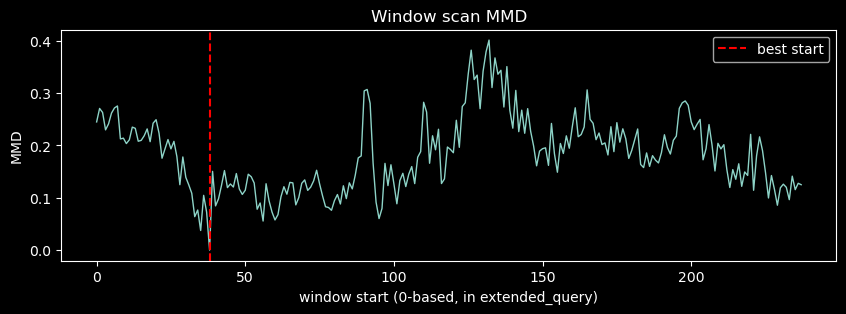

In [10]:
# Visualize window MMD scores
plt.figure(figsize=(10, 3))
plt.plot(starts, mmd_scores, lw=1)
plt.axvline(best_start, color="red", linestyle="--", label="best start")
plt.xlabel("window start (0-based, in extended_query)")
plt.ylabel("MMD")
plt.title("Window scan MMD")
plt.legend()
plt.show()


In [11]:
# Perturb end position around best_start (same as pipeline)
min_len = int(ref_length * min_length_ratio)
max_len = int(ref_length * max_length_ratio)

perturb_records = []
for p in range(-perturbation_range, perturbation_range + 1):
    end = best_end + p
    if end <= best_start or end > query_len:
        continue
    cand_len = end - best_start
    if cand_len < min_len or cand_len > max_len:
        continue
    cand_seq = extended_query[best_start:end]
    cand_emb = embed_token_pca([cand_seq], batch_size=1)[0]
    mmd = sn._compute_mmd_with_ref(ref_ctx, ref_emb, cand_emb)
    perturb_records.append({
        "perturbation": p,
        "end": end,
        "length": cand_len,
        "mmd": mmd,
    })

perturb_df = pd.DataFrame(perturb_records).sort_values("mmd")
perturb_df.head(10)


,perturbation,end,length,mmd
0,-5,99,61,0.000000
1,-4,100,62,0.000000
2,-3,101,63,0.000000
5,0,104,66,0.000000
4,-1,103,65,0.039542
10,5,109,71,0.043074
7,2,106,68,0.052160
6,1,105,67,0.052932
3,-2,102,64,0.056415
9,4,108,70,0.059636


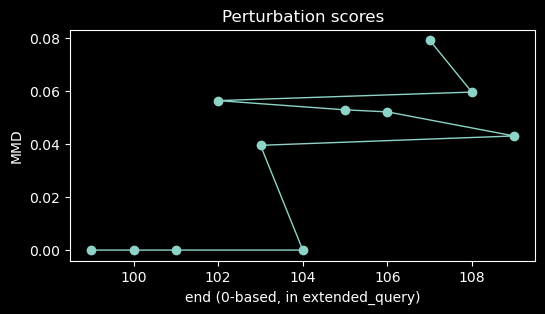

In [12]:
# Plot perturbation MMDs
if not perturb_df.empty:
    plt.figure(figsize=(6, 3))
    plt.plot(perturb_df["end"], perturb_df["mmd"], marker="o", lw=1)
    plt.xlabel("end (0-based, in extended_query)")
    plt.ylabel("MMD")
    plt.title("Perturbation scores")
    plt.show()


In [13]:
# Final predicted region (same logic as pipeline)
if perturb_df.empty:
    raise ValueError("No valid perturbation candidates")

best_perturb = perturb_df.sort_values("mmd").iloc[0]
perturb_best_end = int(best_perturb["end"])

if job.query_strand == 1:
    final_start = ext_start + best_start
    final_end = ext_start + perturb_best_end
else:
    final_end = ext_end - best_start
    final_start = ext_end - perturb_best_end

final_region = f"{q_chrom}:{final_start}-{final_end}"
print("final_region:", final_region)
print("aligned_length:", abs(final_end - final_start))


final_region: chr16:18069226-18069287
aligned_length: 61


In [14]:
# Compare to original query region (help spot misplacement)
orig_start, orig_end = q_start, q_end
pred_start, pred_end = final_start, final_end

print("original:", job.query_region)
print("predicted:", final_region)
print("delta_start:", pred_start - orig_start)
print("delta_end:", pred_end - orig_end)


original: chr16:18069188-18069491
predicted: chr16:18069226-18069287
delta_start: 38
delta_end: -204


## Notes
- If this reproduces a misplacement, save the window MMD curve and perturbation table as evidence.
- If results differ from the pipeline, ensure parameters match (`flank_ratio`, `window_step`, `perturbation_range`, `max_batch`) and that the same ref/query 2bit files are used.
